# Week 1 Seminar

A/B experiment analysis

In [1]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [2]:
experiment = "I2I"

In [3]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in glob.glob("/Users/n.anokhin/Desktop/data/*/data.json")
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [4]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-19 17:16:31.981,5994,11234,1.00,5.018e+00,11231.0,{'I2I': 'T1'},T1
1,next,2026-03-19 17:16:31.989,8123,10431,0.38,5.015e+00,3750.0,{'I2I': 'C'},C
2,next,2026-03-19 17:16:32.016,8123,1158,0.12,1.425e-03,8041.0,{'I2I': 'C'},C
3,last,2026-03-19 17:16:32.015,6953,11909,0.08,5.016e+00,NaN,{'I2I': 'C'},C
4,next,2026-03-19 17:16:32.040,4568,11044,0.38,1.143e-03,5356.0,{'I2I': 'T1'},T1
...,...,...,...,...,...,...,...,...,...
50651,next,2026-03-19 17:19:08.544,550,7629,0.63,4.425e-04,5162.0,{'I2I': 'C'},C
50652,next,2026-03-19 17:19:08.551,550,15409,0.24,4.368e-04,9349.0,{'I2I': 'C'},C
50653,next,2026-03-19 17:19:08.557,550,8616,0.82,4.480e-04,3259.0,{'I2I': 'C'},C
50654,next,2026-03-19 17:19:08.575,2117,1701,1.00,8.166e-04,202.0,{'I2I': 'T1'},T1


In [6]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,56591,56591,56591,56591,56591,56591,50122,56591
T1,65623,65623,65623,65623,65623,65623,58871,65623
T2,80409,80409,80409,80409,80409,80409,73630,80409


## Visualize sessions

In [7]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [8]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_15613/2354129256.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data


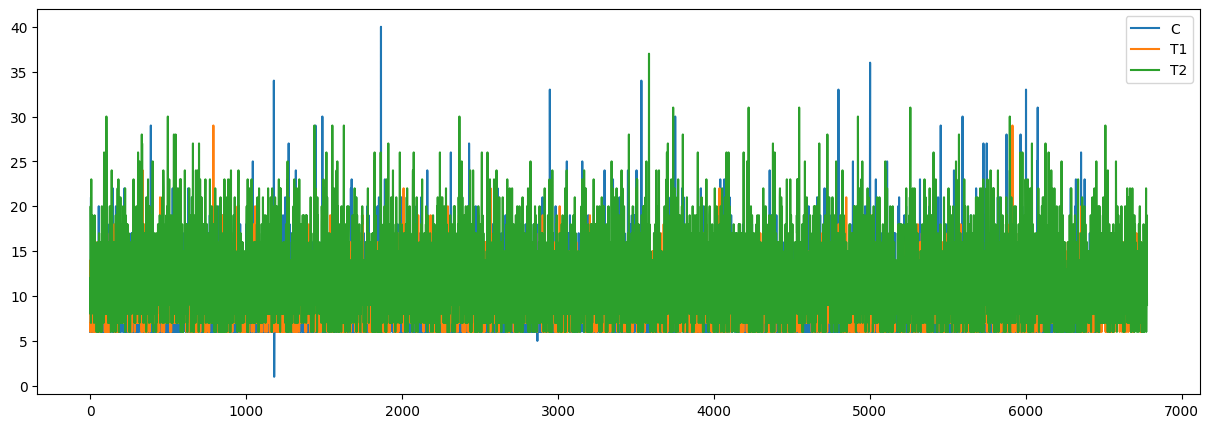

In [9]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

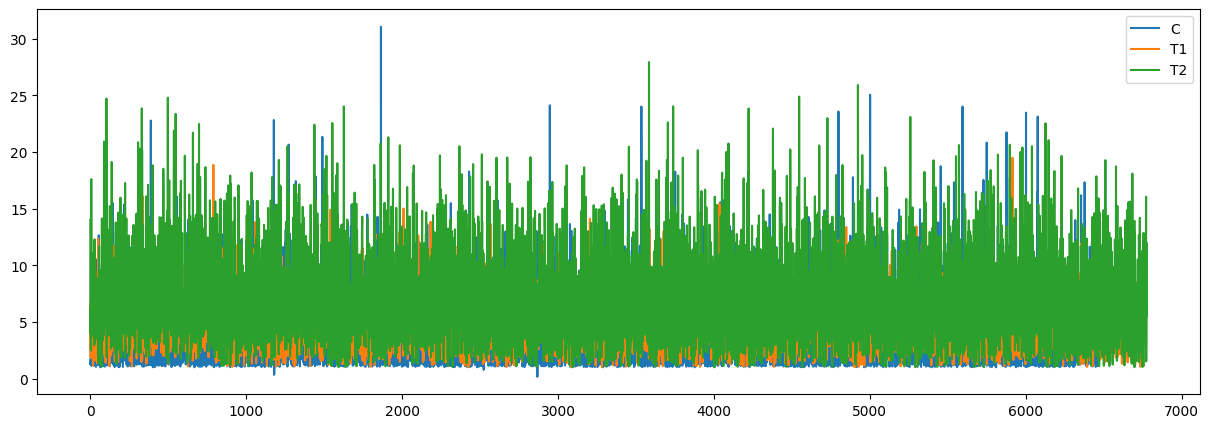

In [10]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [11]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [12]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [13]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [14]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=True)
    .style
    .applymap(color, subset=["effect", "upper", "lower"])
    .applymap(background, subset=["significant"])
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_15613/4013875030.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pd.DataFrame(effects)[[


,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
2,T1,mean_request_latency,28.143950,66.925850,-10.637950,0.656228,0.840917,False
7,T2,mean_request_latency,7.562029,31.169795,-16.045738,0.656228,0.705852,False
4,T1,mean_time_per_session,24.436254,27.694705,21.177803,3.754570,4.672046,True
9,T2,mean_time_per_session,86.824106,91.045510,82.602702,3.754570,7.014442,True
3,T1,mean_tracks_per_session,10.418135,12.010898,8.825372,8.743704,9.654635,True
8,T2,mean_tracks_per_session,37.245972,39.228455,35.263489,8.743704,12.000382,True
1,T1,sessions,1.499374,4.364463,-1.365715,2.290722,2.325069,False
6,T2,sessions,2.718795,5.586623,-0.149033,2.290722,2.353002,False
0,T1,time,27.926642,32.820261,23.033023,8.596979,10.997827,True
5,T2,time,87.952083,93.987479,81.916688,8.596979,16.158202,True
